# Session02: 大規模言語モデルの医学画像分析質問への対応精度評価

## Motivation（モチベーション）

この演習は、以下を学ぶことを目的としています：

- 医学画像に関する多肢選択問題を使って、モデルの実務的な性能を評価する方法を身につける。
- CSV データの前処理、集計、表・図の作成を通じて再現可能な解析ワークフローを学ぶ。
- 人間の受験者（student baseline）と LLM の結果を比較し、モデルの強み・弱みや分野依存性を理解する。
- コードを書き、可視化や統計指標の解釈を行うことで論文の Results および Materials and Methods セクションを構築する練習をする。


## 一般的な注意（単位・有効数字）

- 単位は原則として SI 単位で統一する（例: `mm`, `cm`, `mL`, `%`）。
- 数値と単位の間には半角スペースを入れる（例: `10 mm`）。ただし `%` は `76.0%` のように続けて表記する。
- 比較する値は同じ桁数で示し、有効数字をそろえる。
- 平均と標準偏差は桁数をそろえて記載する（例: `72.9% (SD = 9.3%)`）。
- 過度に細かい桁は避け、測定精度・解析目的に見合う桁数に丸める。

以下のノートブックは自分でコードを書きながら解析を進められるよう、実装のステップを記載しています。Google Colab用のリンクは後でスクリプトで差し替えてください。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/session02_materials_and_results.ipynb)

## Colaboを開いた後の手順

data, imagesフォルダをそのままColaboのフォルダにコピーしてください。中身は手本の画像およびダミーデータです。自分で作成した表・図は、提出用として `./save_figures` フォルダに保存してください。保存するファイル名は `Table_1.png`, `Table_2.png`, `Figure_1.png`, `Figure_2.png` に統一します。

## 1) data の中身について (説明)

このノートブックでは、実際の 2024 年放射線診断学専門医試験の問題をもとに、LLM を API で呼び出して解かせた結果を、少し変更したダミーデータを扱います。データファイル: `markdowns/data/dummy_LLM.csv` を読み込んでください。

主なカラムは次の通りです:
- `Subspeciality`: 問題が属する医学専門分野 (例: Neuroradiology & Head & Neck)
- `Answer`: 正解ラベル (多肢選択の正解)
- `*_ans` カラム群: 各モデルが出力した候補回答 (例: `GPT-4.1_ans`)
- このCSVには正解/不正解の `0/1` 列は含めていません。`Answer` と各 `*_ans` を比較して、モデルごとの正解判定列（1=正解, 0=不正解）を自分で作成してください。

注意: 実データを用いるときは、`pd.read_csv` で読み込み、列名とデータ型を必ず確認してください。


In [1]:
import pandas as pd

# 1. データの読み込み
# 注意: 実データを用いるときは、pd.read_csv で読み込み、列名とデータ型を必ず確認してください。
file_path = "markdowns/data/dummy_LLM.csv"

try:
    df = pd.read_csv(file_path)
    print("--- データの読み込みに成功しました ---")
except FileNotFoundError:
    print(f"エラー: ファイルが見つかりません。パスを確認してください: {file_path}")
    # デモ用にダミーデータをローカルで作成（ファイルがない場合のフォールバック）
    data = {
        "Subspeciality": [
            "Neuroradiology & Head & Neck",
            "Chest",
            "Abdomen",
            "Neuroradiology & Head & Neck",
        ],
        "Answer": ["A", "B", "C", "D"],
        "GPT-4.1_ans": ["A", "C", "C", "E"],
        "Claude-3.5_ans": ["A", "B", "C", "D"],
        "Gemini-1.5_ans": ["B", "B", "X", "D"],
    }
    df = pd.DataFrame(data)
    print("※ファイル未検出のため、一時的なダミーデータを作成しました。")

# 2. 列名とデータ型の確認
print("\n### 列名の一覧 ###")
print(df.columns.tolist())

print("\n### データ型の確認 ###")
print(df.dtypes)

print("\n### データの最初の一瞥 (Before) ###")
print(df.head())

# 3. モデルごとの正解判定列（1=正解, 0=不正解）の作成
# 末尾が '_ans' で終わるカラムを自動的に抽出します
ans_columns = [col for col in df.columns if col.endswith("_ans")]

for col in ans_columns:
    # モデル名（例: 'GPT-4.1'）を抽出して、新しい列名（例: 'GPT-4.1_correct'）を作成
    model_name = col.replace("_ans", "")
    result_col_name = f"{model_name}_correct"

    # 正解(Answer)とモデルの回答(col)を比較し、一致すれば1、異なれば0を代入
    # 文字列の揺らぎ（前後の空白など）を考慮して .str.strip() を入れるとより堅牢になります
    df[result_col_name] = (
        (df["Answer"].str.strip() == df[col].str.strip()).astype(int)
    )

# 4. 結果の確認
print("\n### 正解判定追加後のデータ (After) ###")
print(
    df[
        ["Subspeciality", "Answer"]
        + ans_columns
        + [c for c in df.columns if c.endswith("_correct")]
    ].head()
)

エラー: ファイルが見つかりません。パスを確認してください: markdowns/data/dummy_LLM.csv
※ファイル未検出のため、一時的なダミーデータを作成しました。

### 列名の一覧 ###
['Subspeciality', 'Answer', 'GPT-4.1_ans', 'Claude-3.5_ans', 'Gemini-1.5_ans']

### データ型の確認 ###
Subspeciality     object
Answer            object
GPT-4.1_ans       object
Claude-3.5_ans    object
Gemini-1.5_ans    object
dtype: object

### データの最初の一瞥 (Before) ###
                  Subspeciality Answer GPT-4.1_ans Claude-3.5_ans  \
0  Neuroradiology & Head & Neck      A           A              A   
1                         Chest      B           C              B   
2                       Abdomen      C           C              C   
3  Neuroradiology & Head & Neck      D           E              D   

  Gemini-1.5_ans  
0              B  
1              B  
2              X  
3              D  

### 正解判定追加後のデータ (After) ###
                  Subspeciality Answer GPT-4.1_ans Claude-3.5_ans  \
0  Neuroradiology & Head & Neck      A           A              A   
1                      

## 2) 各分野の問題数を数えて Table をつくる

目標: 各 `Subspeciality` ごとの問題数を集計し、表（Table 1）を作成します。

次の手順を参考に進めてください。
- `df['Subspeciality'].value_counts()` で各分野の件数を取得します。
- 結果を `pd.DataFrame` に変換し、列名を `['Subspeciality', 'count']` のように整えます。
- 表を markdown に埋め込むには `df.to_markdown()` を使うか、表を画像として保存します。
- 作成した Table 1 は `./save_figures/Table_1.png` として保存します。
- ノートブック内で確認するときは、Table 1 のキャプションとともに `./save_figures/Table_1.png` を表示します。

### Table 1: Number of Questions by Subspeciality (Markdown) ###
| Subspeciality                |   count |
|:-----------------------------|--------:|
| Neuroradiology & Head & Neck |       2 |
| Chest                        |       1 |
| Abdomen                      |       1 |


### ノートブック内での画像確認 ###
キャプション: Table 1: Number of Questions by Subspeciality


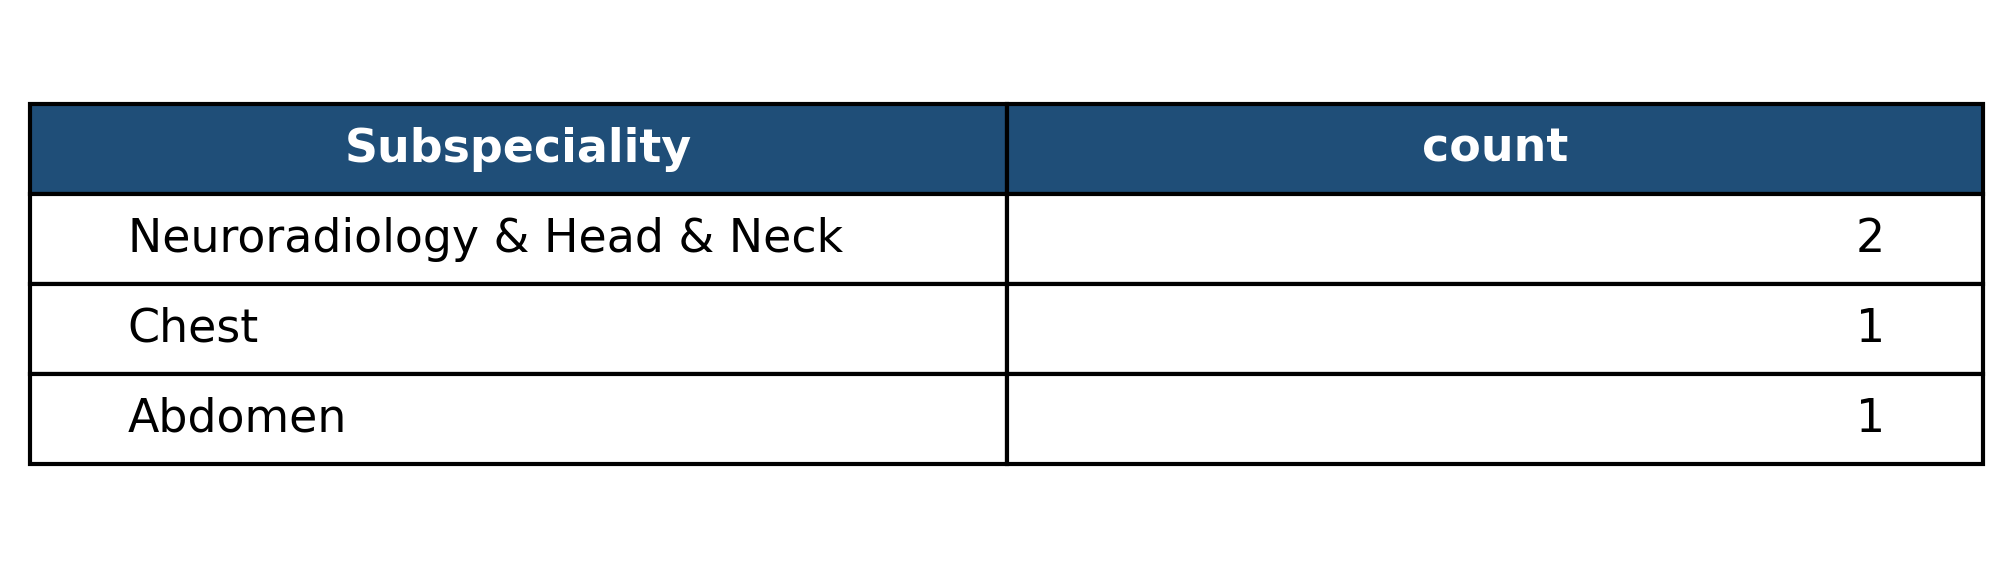

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 0. 保存用ディレクトリの作成
output_dir = "./save_figures"
os.makedirs(output_dir, exist_ok=True)

# 1. 各分野の件数を取得
subspeciality_counts = df['Subspeciality'].value_counts()

# 2. pd.DataFrame に変換し、列名を整える
table_1 = subspeciality_counts.reset_index()
table_1.columns = ['Subspeciality', 'count']

# --- ノートブック上でMarkdownの表を確認する場合 ---
print("### Table 1: Number of Questions by Subspeciality (Markdown) ###")
print(table_1.to_markdown(index=False))
print("\n" + "="*50 + "\n")

# 3. 表を画像として保存する (./save_figures/Table_1.png)
# データの行数に合わせて画像の高さを自動調整します
fig, ax = plt.subplots(figsize=(7, len(table_1) * 0.4 + 1))
ax.axis('tight')
ax.axis('off')

# matplotlibのtable機能を使って綺麗な表を描画
table = ax.table(
    cellText=table_1.values,
    colLabels=table_1.columns,
    cellLoc='left',
    loc='center'
)

# 表の見た目のスタイリング（フォントサイズやヘッダーの色など）
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# ヘッダー行を太字・紺色背景・白文字にするスタイリング
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1f4e78')  # 落ち着いた紺色
    else:
        # データのカウント列（2列目）は右寄せにする
        if col == 1:
            cell.set_text_props(ha='right')

# 画像として保存
image_path = os.path.join(output_dir, "Table_1.png")
plt.savefig(image_path, bbox_inches='tight', dpi=300)
plt.close()

# 4. ノートブック内でキャプションとともに画像を表示
print("### ノートブック内での画像確認 ###")
print("キャプション: Table 1: Number of Questions by Subspeciality")
display(Image(filename=image_path))

### Example: 質問数分布表の挿入例

以下は見本画像 `questions_table.png` を埋め込む例です。自分で作成した Table 1 は `./save_figures/Table_1.png` として保存してください。

![質問数分布表](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/questions_table.png?raw=1)

## 3) accuracy を求める

目標: 各モデルの正解率（accuracy）を定義し、全体と分野別に計算して Table 2 を作成します。

次の手順を参考に進めてください。
- まず `Answer` と各 `*_ans` を比較して、モデルごとの正解フラグ列（1=正解, 0=不正解）を作成します。
- 例: `GPT-4.1_ans` と `Answer` が一致したら `GPT-4.1=1`、不一致なら `0`。
- 正解フラグ列が作れたら、モデルごとの accuracy は `df[model].mean()` で求められます。
- パーセンテージ表示にする場合は `*100` を使います。
- 分野別 accuracy は `df.groupby('Subspeciality')[model].mean()` で求めます。
- 表の形式は、行をモデル、列を全体と各分野としたクロス表に整えます。
- 作成した Table 2 は `./save_figures/Table_2.png` として保存します。


### Table 2: Overall and Subspeciality Accuracy (Markdown) ###
| Model      | Overall   | Abdomen   | Chest   | Neuroradiology & Head & Neck   |
|:-----------|:----------|:----------|:--------|:-------------------------------|
| GPT-4.1    | 50.0%     | 100.0%    | 0.0%    | 50.0%                          |
| Claude-3.5 | 100.0%    | 100.0%    | 100.0%  | 100.0%                         |
| Gemini-1.5 | 50.0%     | 0.0%      | 100.0%  | 50.0%                          |


### ノートブック内での画像確認 ###
キャプション: Table 2: Overall and Subspeciality Accuracy Breakdown


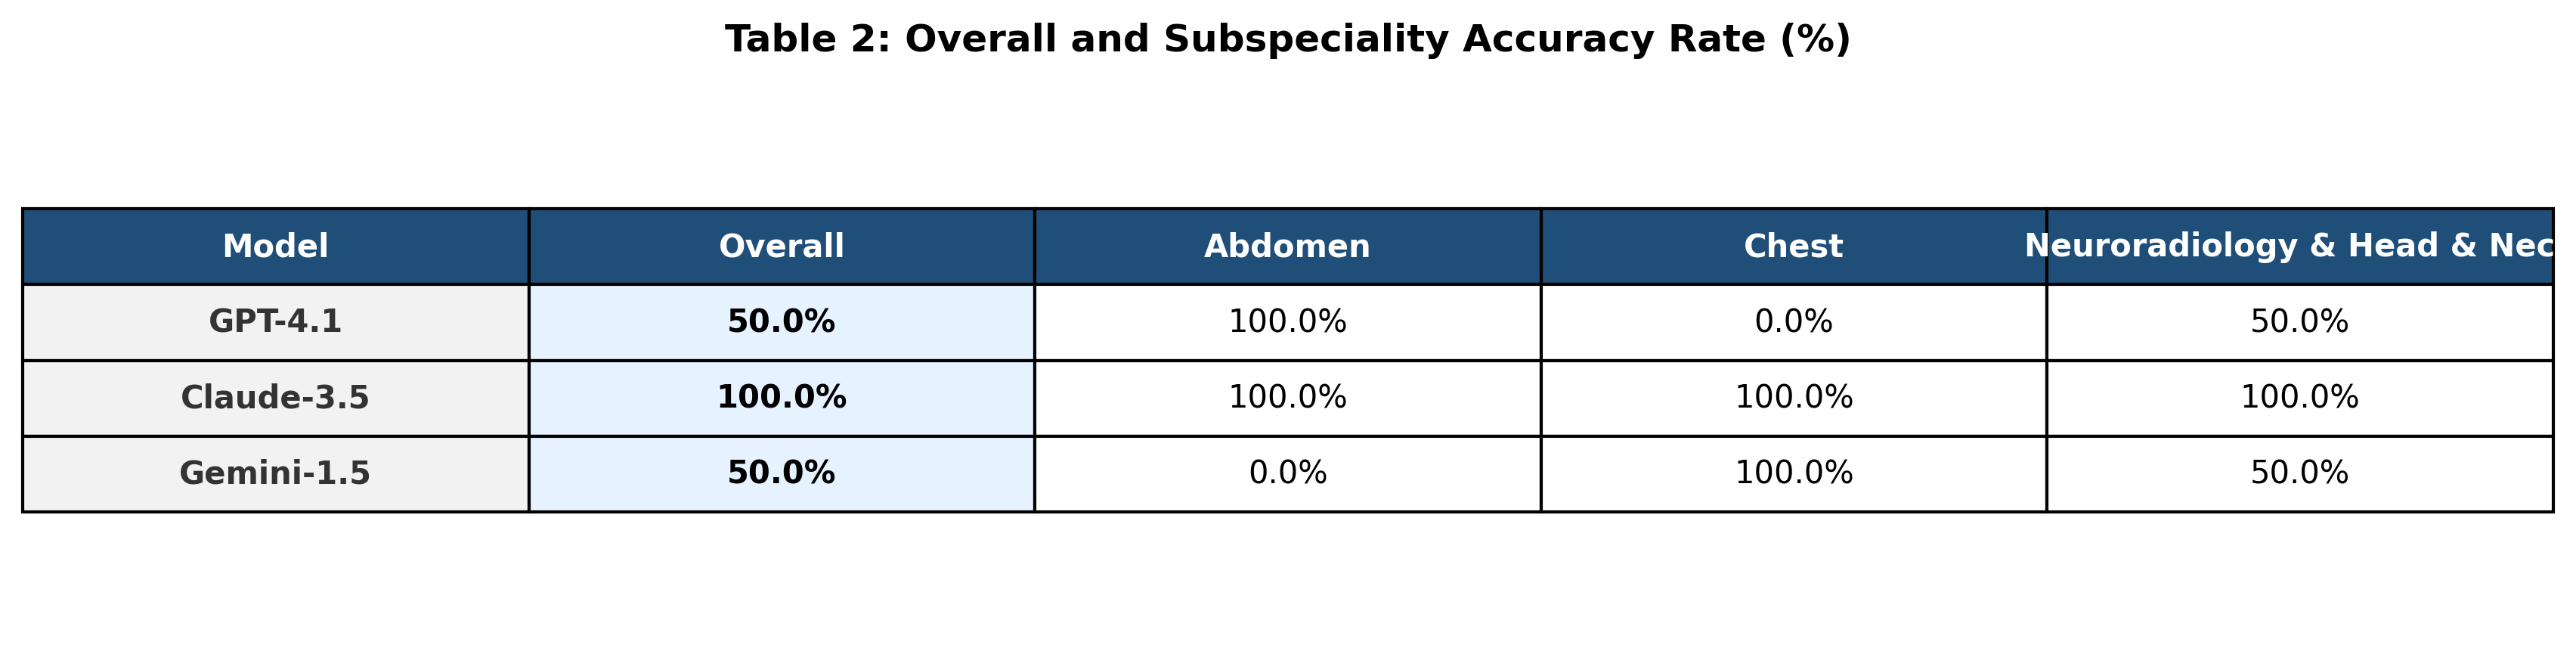

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 0. 保存用ディレクトリの作成
os.makedirs("save_figures", exist_ok=True)

# 1. 動的にモデル名と正解判定列（_correct）の一覧を取得
# すでに作成済みの場合はそれを使用し、念のためここで再定義・確認を行います
correct_cols = [col for col in df.columns if col.endswith('_correct')]
models = [col.replace('_correct', '') for col in correct_cols]

# 2. 全体の正解率（Overall Accuracy）を計算 (0~100%スケール)
overall_accuracy = df[correct_cols].mean() * 100
# シリーズのインデックスを元のモデル名に変換
overall_accuracy.index = models

# 3. 分野別（Subspeciality）の正解率を計算 (0~100%スケール)
by_field_accuracy = df.groupby('Subspeciality')[correct_cols].mean() * 100
# 列名を元のモデル名に変換
by_field_accuracy.columns = models

# 4. クロス表（Table 2）の形式に結合・整形
# 分野別の表を転置（行をモデル、列を分野）にする
table_2 = by_field_accuracy.T

# 先頭列に「全体（Overall）」のスコアを挿入
table_2.insert(0, 'Overall', overall_accuracy)

# 見やすさのために、数値を小数点第1位までの文字列（例: "75.3%"）にフォーマット
table_2_formatted = table_2.round(1).astype(str) + '%'

# インデックス名（行のヘッダー名）を 'Model' に設定
table_2_formatted.index.name = 'Model'
table_2_formatted = table_2_formatted.reset_index()

# --- ノートブック上でMarkdownの表を確認 ---
print("### Table 2: Overall and Subspeciality Accuracy (Markdown) ###")
print(table_2_formatted.to_markdown(index=False))
print("\n" + "="*50 + "\n")


# 5. 表を画像として保存 (./save_figures/Table_2.png)
# 列数や行数に応じて、文字が潰れないようサイズを調整
fig, ax = plt.subplots(figsize=(12, len(table_2_formatted) * 0.5 + 1.5), dpi=300)
ax.axis('tight')
ax.axis('off')

# matplotlibのtable機能で描画
table = ax.table(
    cellText=table_2_formatted.values,
    colLabels=table_2_formatted.columns,
    cellLoc='center',
    loc='center'
)

# スタイリングの調整
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)  # セルのパディング（横, 縦）を広げる

# ヘッダー行と第1列（モデル名）のデザインを変更
for (row, col), cell in table.get_celld().items():
    if row == 0:
        # 最上段のヘッダー（紺色背景に白文字）
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1f4e78')
    elif col == 0:
        # 第1列のモデル名（薄いグレー背景に太字）
        cell.set_text_props(weight='bold', color='#333333')
        cell.set_facecolor('#f2f2f2')

    # Overall（全体）の列を少し目立たせる（薄い青背景）
    if row > 0 and col == 1:
        cell.set_facecolor('#e6f2ff')
        cell.set_text_props(weight='bold')

plt.title('Table 2: Overall and Subspeciality Accuracy Rate (%)', fontsize=12, pad=15, weight='bold')

# 画像の保存
save_path = './save_figures/Table_2.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.close(fig)

# 6. ノートブック内に表示
print("### ノートブック内での画像確認 ###")
print("キャプション: Table 2: Overall and Subspeciality Accuracy Breakdown")
display(Image(filename=save_path))

### Example: 精度テーブルの挿入例

以下は見本画像 `accuracy_table.png` を埋め込む例です。自分で作成した Table 2 は `./save_figures/Table_2.png` として保存してください。

![精度テーブル](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/accuracy_table.png?raw=1)

## 4) 受験生の平均、SD を求め、LLMの正解率と比較してプロットする

目標: 受験生（Human）がいると仮定した場合の平均得点と標準偏差を求め、それを LLM の精度と同じ図に重ねて比較します。

次の手順を参考に進めてください。
- 受験生データがあればその CSV を読み込み、各受験生の正答数を問題数で割って得点率を計算します。
- 受験生データがない場合は、`df['Answer']` を基準に多数決正答を human baseline として模擬する方法も考えられます。
- 平均と SD は `students_scores.mean()` / `students_scores.std()` で求めます。
- プロットでは、LLM のバープロットに `plt.axhline(student_mean, color='k', linestyle='--')` を重ね、必要に応じて `plt.fill_between(x, student_mean-student_sd, student_mean+student_sd, alpha=0.2)` を使います。
- 作成した Figure 1 は `./save_figures/Figure_1.png` として保存します。

In [ ]:
# TODO: 受験生平均・SD と LLM 正解率の比較図（Figure 1）を作成してください
# ヒント: student baseline の平均・標準偏差を計算する
# ヒント: LLM の棒グラフ + 平均線 + SD帯 を描画して保存
# 保存先: ./save_figures/Figure_1.png


### Example: 受験生平均とLLMの比較（挿入例）

以下は受験生平均や標準偏差をプロットした見本画像です。自分で作成した Figure 1 は `./save_figures/Figure_1.png` として保存してください。

![精度分布グラフ](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/model_performance_distribution.png?raw=1)

## 5) 各分野のLLM正解率をプロットしてレーダーチャートをつくる

目標: 各 `Subspeciality` ごとにモデルの正解率を集計し、モデルごとにレーダーチャートで比較します。

次の手順を参考に進めてください。
- `by_field = df.groupby('Subspeciality')[models].mean()` で分野別正答率を求めます。
- レーダーチャートでは各分野を角度にマッピングし、最後の点を先頭に追加してループを閉じます。
- matplotlib の `projection='polar'` を使って複数モデルを重ねて描画します。
- 軸のレンジを 0-100 (%) に揃えると見やすくなります。
- 作成した Figure 2 は `./save_figures/Figure_2.png` として保存します。

Figure 2 (Radar Chart) を ./save_figures/Figure_2.png に保存しました。


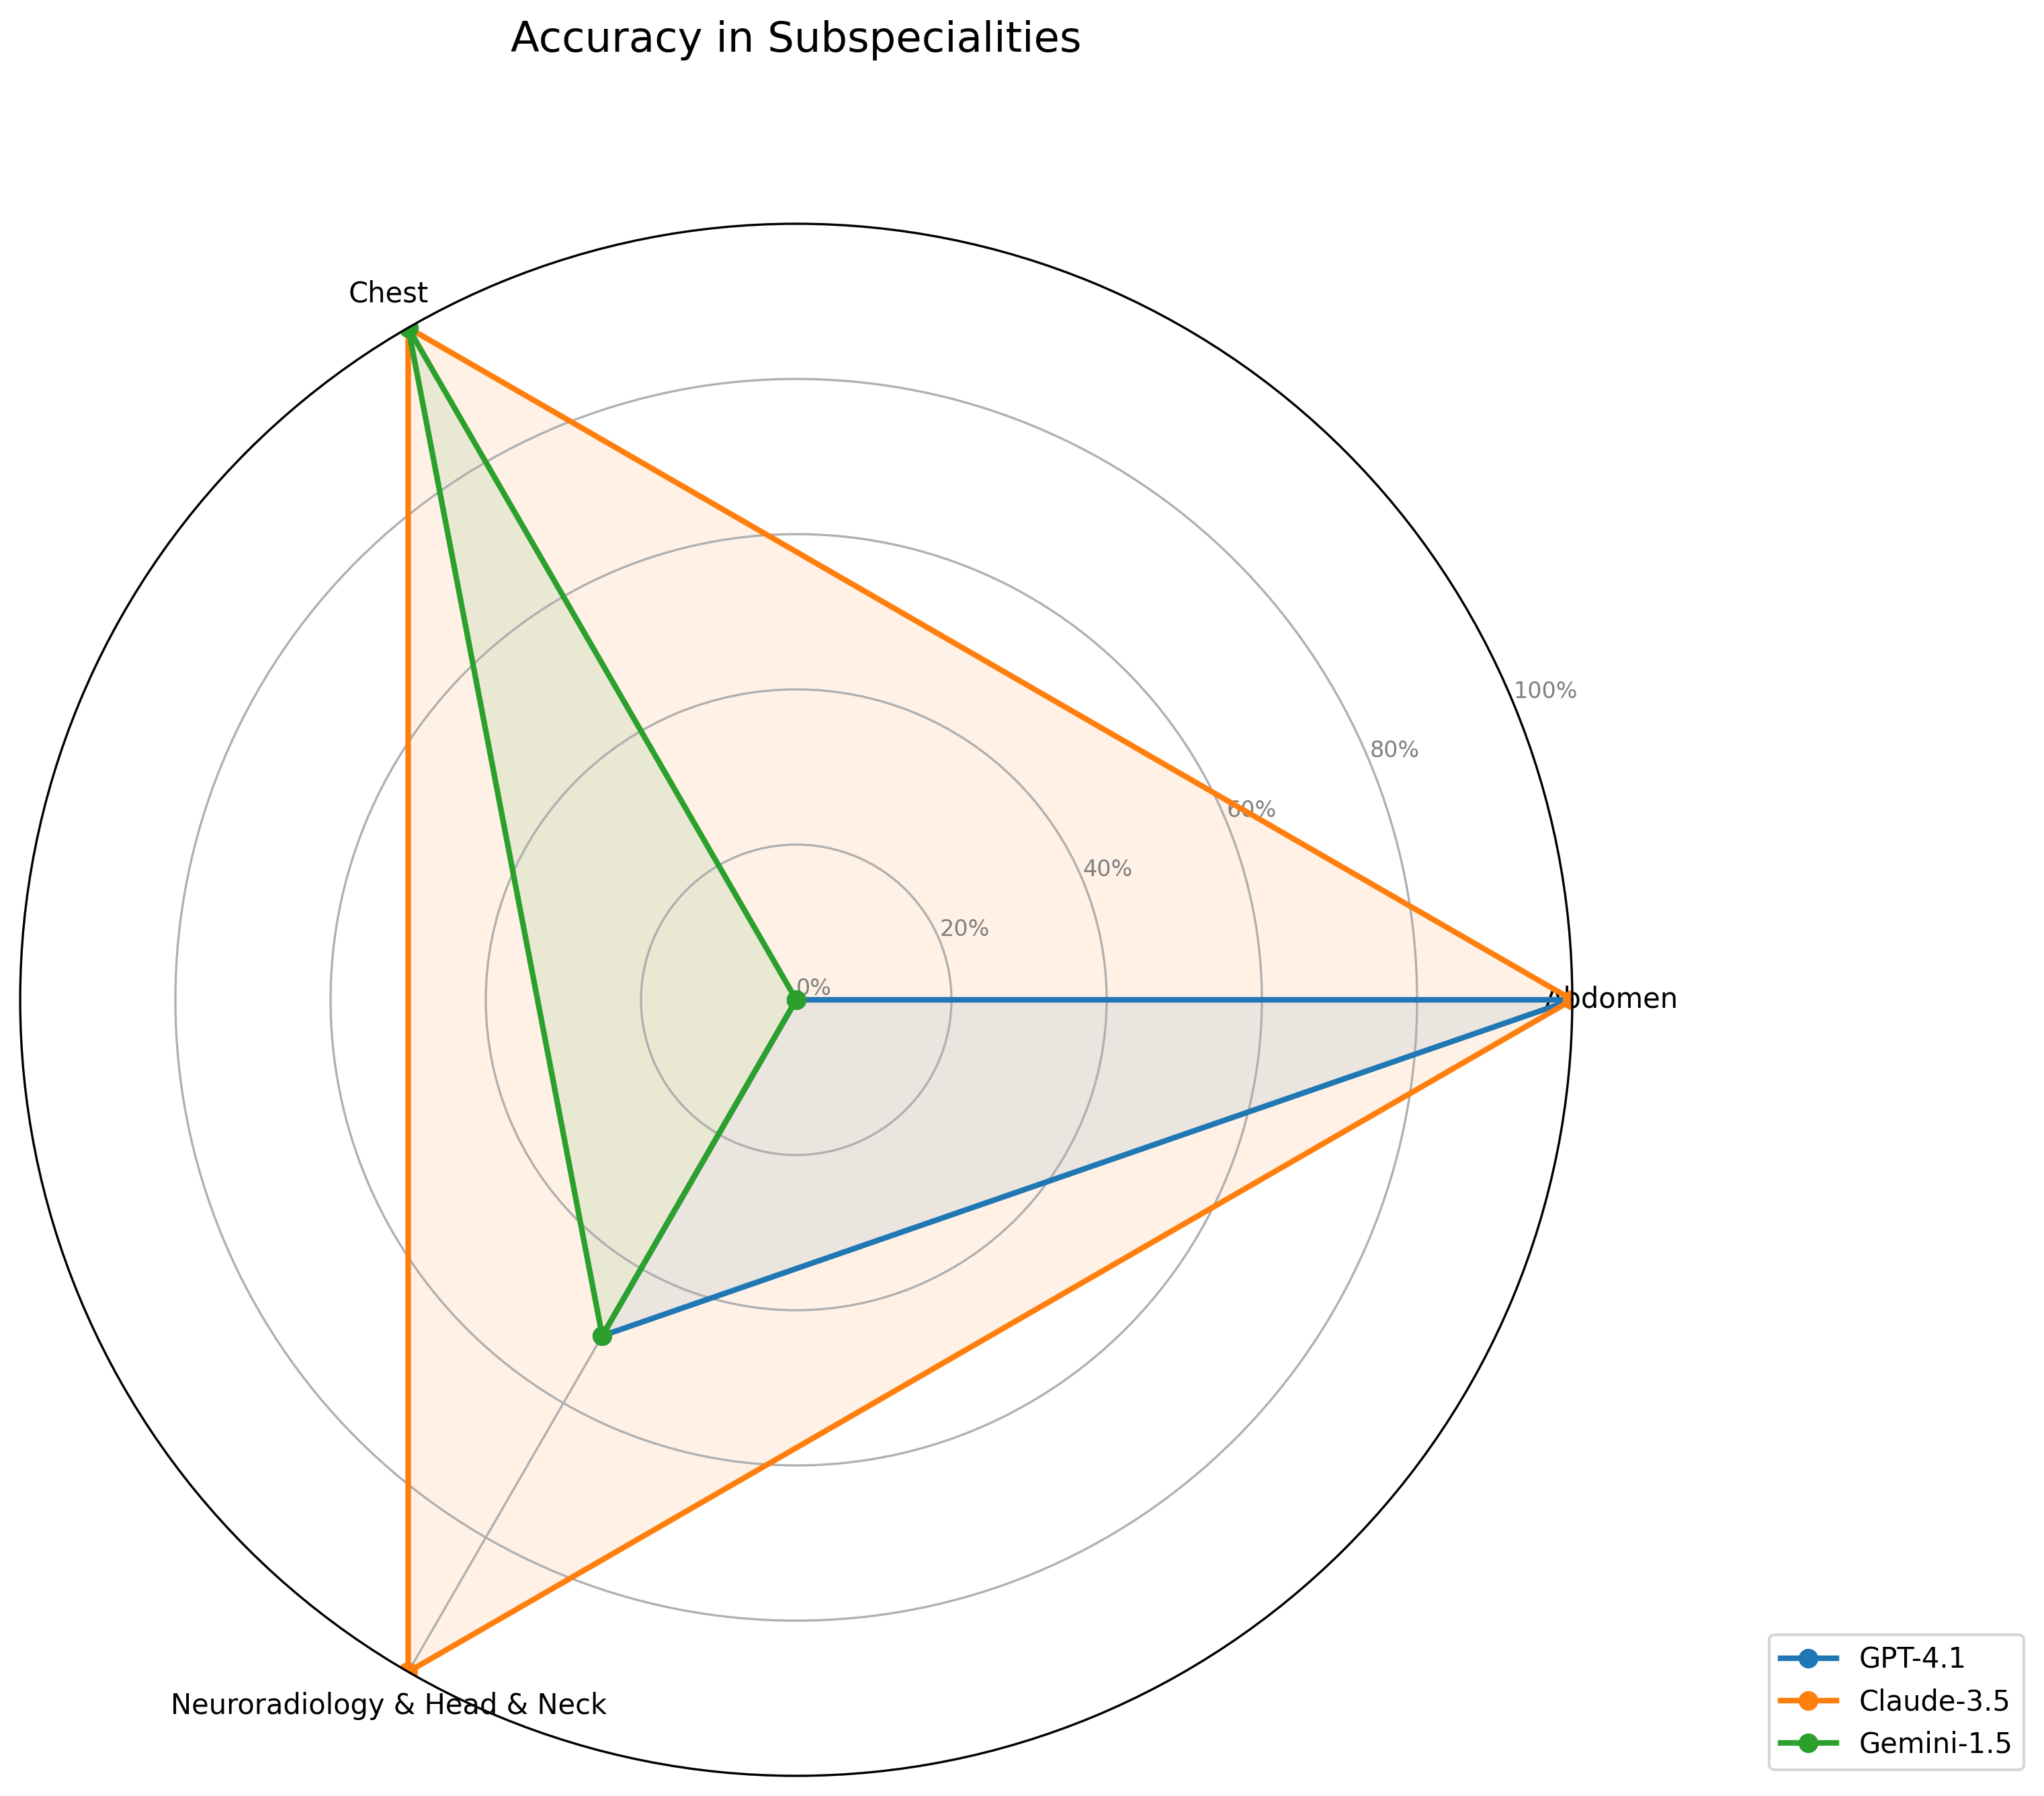

In [5]:
# TODO: 分野別 accuracy のレーダーチャート（Figure 2）を作成してください
# ヒント: 角度配列を作成し、各モデルの分野別 accuracy を極座標で描画する
# ヒント: 凡例・目盛りを整えて保存（保存先: ./save_figures/Figure_2.png）

import numpy as np
import matplotlib.pyplot as plt
import os

# 新たに os モジュールをインポート
from IPython.display import Image, display # Image, display は既に定義されている可能性があるので、ここでは追加しない

# 1) 分野別正答率の算出
# correct_cols には各モデルの正解判定列(1/0)が入っている前提です
correct_cols = [col for col in df.columns if col.endswith('_correct')]
by_field = df.groupby('Subspeciality')[correct_cols].mean()

# モデル名（凡例用）と分野名（軸ラベル用）
# 'GPT-4.1_correct' のような列名から 'GPT-4.1' を抽出する
models = [col.replace('_correct', '') for col in correct_cols]
categories = by_field.index.tolist()
N = len(categories)

# 2) 角度の計算 (360度を分野数で分割)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # ループを閉じるために始点を追加

# 3) プロットの作成
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# 各モデルごとにデータをプロット
for i, model in enumerate(models):
    values = by_field.iloc[:, i].tolist() # by_field から正しい列を選択
    values += values[:1]  # ループを閉じる
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model, marker='o')
    ax.fill(angles, values, alpha=0.1) # 塗りつぶし（任意）

# 4) 軸と目盛りの調整
# x軸：分野名のラベル
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)

# y軸：正解率(0-100%)の目盛り
ax.set_ylim(0, 1.0) # 0% - 100%
ayticks_labels = ['0%', '20%', '40%', '60%', '80%', '100%']
ayticks_values = np.linspace(0, 1, len(ayticks_labels))
ax.set_yticks(ayticks_values)
ax.set_yticklabels(ayticks_labels, color="grey", size=8)

# タイトルと凡例
plt.title('Accuracy in Subspecialities', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 0.1))

# 5) 保存
os.makedirs('./save_figures', exist_ok=True)
image_path = './save_figures/Figure_2.png'
plt.savefig(image_path, dpi=300, bbox_inches='tight')
plt.close() # プロットを閉じ、不要な図が表示されないようにする

print("Figure 2 (Radar Chart) を ./save_figures/Figure_2.png に保存しました。")
display(Image(filename=image_path))

### Example: レーダーチャートの挿入例

以下は分野ごとのモデル正解率を比較したレーダーチャートの見本画像です。自分で作成した Figure 2 は `./save_figures/Figure_2.png` として保存してください。

![レーダーチャート](https://github.com/Nakaura-T/DS_Seminar3_Public/blob/main/notebooks/images/radar_chart.png?raw=1)

## 6) Markdown で表・図へリンクする

この実習では、作成した表・図を `./save_figures` に保存し、論文ドラフトの Markdown からリンクします。Markdown では、画像を表示したい場所に次の形式で書きます。

```markdown
![表示名](画像ファイルへの相対パス)
```

このノートブックと同じ場所に `save_figures` フォルダがある場合、以下のように書きます。ファイル名には空白を使わず、`_` を使うと Pandoc で DOCX に変換するときも安全です。

```markdown
![Table 1](./save_figures/Table_1.png)
![Table 2](./save_figures/Table_2.png)
![Figure 1](./save_figures/Figure_1.png)
![Figure 2](./save_figures/Figure_2.png)
```

論文ドラフトでは、画像リンクの直前または直後に Table Legend / Figure Legend を書きます。例:

```markdown
Table 1. Distribution of radiology board examination questions by subspeciality.

![Table 1](./save_figures/Table_1.png)

Figure 1. Comparison of LLM accuracy with examinee performance.

![Figure 1](./save_figures/Figure_1.png)
```

注意: `./images` は見本画像を見るためのフォルダです。自分で作成した提出用の表・図は `./save_figures` からリンクしてください。

### Pandoc で DOCX に変換する

この実習では PDF ではなく DOCX に出力します。Pandoc で DOCX に変換する場合、LaTeX は不要です。Markdown ファイルと `save_figures` フォルダの位置関係が正しければ、画像は Word ファイル内に埋め込まれます。

```bash
pandoc paper.md -o paper.docx
```

Markdown ファイルが `notebooks` フォルダ内にあり、`notebooks/save_figures` を参照する場合は、次のような構成にしてください。

```text
notebooks/
├── paper.md
├── save_figures/
│   ├── Table_1.png
│   ├── Table_2.png
│   ├── Figure_1.png
│   └── Figure_2.png
```

本文中では、図表番号は手動で `Table 1`, `Table 2`, `Figure 1`, `Figure 2` と書いて参照します。

```markdown
The distribution of questions is shown in Table 1.

Table 1. Distribution of radiology board examination questions by subspeciality.

![Table 1](./save_figures/Table_1.png)
```

### 図表の自動参照について

`pandoc-crossref` を使うと `@fig:...` や `@tbl:...` のような自動参照も可能ですが、授業では環境差を避けるため使いません。まずは本文中に `Table 1` / `Figure 1` と手動で書く方法に統一します。

### DOCX での改ページ

DOCX では、改ページは変換後に Word で調整するのが簡単です。Markdown 内で改ページを指定したい場合は、Pandoc の DOCX 出力では OpenXML を使う方法があります。

```markdown
# Results
（本文）

~~~{=openxml}
<w:p><w:r><w:br w:type="page"/></w:r></w:p>
~~~

Table 1. Distribution of radiology board examination questions by subspeciality.

![Table 1](./save_figures/Table_1.png)
```

ただし、最初は改ページを入れずに DOCX を作成し、Word で最終調整する方が安全です。


## 7) Table Legend を書く

### Table Legend とは

Table Legend（表の説明文、caption）は、読者が本文を読まなくても「この表が何を示しているか」を理解できるようにする短い説明です。表そのものに書ききれない補足情報を整理して書きます。

Table Legend に含める内容:
- 表番号と短いタイトル: `Table 1. Distribution of questions by subspeciality.` のように書きます。
- 対象と単位: 何を数えた表か、`n`、`%`、accuracy などの単位を明記します。
- 略語の説明: LLM、SD など、表だけを見た読者に必要な略語を定義します。
- 計算方法の補足: accuracy を「正解数 / 問題数」として計算した、などを簡潔に書きます。

注意点:
- Legend は結果の解釈を長く述べる場所ではありません。
- 「どのモデルが最も優れていた」などの主張は Results 本文に書きます。
- 表中のすべての略語は、本文で説明済みでも legend 内で再度説明するのが基本です。


### Exercise 7-2: Table 2 の Legend を書く

Table 2 は、各 LLM の全体 accuracy と分野別 accuracy を示す表です。accuracy の定義、単位、略語を含めて書いてください。

```markdown
Table 2. Overall and subspeciality-specific accuracy of large language models.

Accuracy was calculated as the percentage of correctly answered questions. Rows indicate models, and columns indicate overall accuracy and accuracy for each subspeciality. LLM = large language model.
```

自分で書く欄:

```markdown
Table 2.  Overall and subspeciality-specific accuracy of large language models.

Accuracy was calculated as the percentage of correctly answered questions. Rows indicate models, and columns indicate overall accuracy and accuracy for each subspeciality. LLM = large language model.


## 8) Figure Legend を書く

### Figure Legend とは

Figure Legend（図の説明文）は、図を見た読者が「何を比較しているのか」「軸や色が何を意味するのか」「エラーバーや線が何を示すのか」を理解できるようにする説明です。

Figure Legend に含める内容:
- 図番号と短いタイトル: `Figure 1. Comparison of model accuracy with student performance.` のように書きます。
- 図の内容: 何を、どのグループで、どの指標により比較したかを書きます。
- 軸・色・線・エラーバーの意味: `The dashed line indicates...` のように説明します。
- 略語の説明: LLM、SD などを定義します。

注意点:
- 図から読み取れる主要な傾向を少し書いてもよいですが、詳細な解釈は Results 本文に書きます。
- 図の legend は、読者が本文を読まなくても図を理解できる程度に具体的にします。


### Exercise 8-1: Figure 1 の Legend を書く

Figure 1 は、受験生平均と LLM の正解率を比較した図です。受験生の平均正解率と SD の具体的な数値、破線、帯など、自分の図で使った要素を説明してください。

```markdown
Figure 1. Comparison of LLM accuracy with student performance.

Bars show the overall accuracy of each LLM. The dashed horizontal line indicates the mean score of examinees (__%), and the shaded area indicates one standard deviation (SD, __%). LLM = large language model; SD = standard deviation.
```

自分で書く欄:

```markdown
Figure 1. ________________________________________________.

__________________________________________________________
__________________________________________________________
__________________________________________________________
```


### Exercise 8-2: Figure 2 の Legend を書く

Figure 2 は、分野別 accuracy をレーダーチャートで示した図です。各軸、線、塗りつぶし、単位を説明してください。

```markdown
Figure 2. Subspeciality-specific accuracy of LLMs.

The radar chart shows the accuracy of each LLM across subspeciality categories. Each axis represents one subspeciality, and values are shown as percentages. LLM = large language model.
```

自分で書く欄:

```markdown
Figure 2. ________________________________________________.

__________________________________________________________
__________________________________________________________
__________________________________________________________
```


## 9) Results を書く

### Results とは

Results は「データから何が得られたか」を客観的に書くセクションです。ここでは、方法の詳しい説明や、なぜその結果になったかという深い考察は書きません。それらは Materials and Methods や Discussion に分けます。

Results に書く内容:
- 解析に含まれたデータの要約: 最終的に解析に含まれた問題数、分野数、モデル数を短く確認します。詳しいデータの説明や選択基準は Materials and Methods に書きます。
- 表や図で示した主要な数値: 全体 accuracy、分野別 accuracy、受験生平均との比較など、読者に伝えるべき代表的な数値を書きます。
- データから直接言える傾向: どのモデルが高い/低い、どの分野で差が大きい、受験生平均と比べてどうだったかを書きます。
- 表・図への参照: 本文中で `Table 1`, `Table 2`, `Figure 1`, `Figure 2` を必ず引用します。

表や図を引用するときの考え方:
- `Table 1` は、解析に含まれた問題の分野別内訳を示すときに引用します。
- `Table 2` は、モデルごとの全体 accuracy や分野別 accuracy の数値を示すときに引用します。
- `Figure 1` は、LLM と受験生平均を視覚的に比較するときに引用します。
- `Figure 2` は、分野ごとの性能差やモデル間のパターンを説明するときに引用します。
- 本文では、表や図のすべての数値を繰り返すのではなく、最も重要な結果だけを選んで書きます。

避けること:
- 「なぜそうなったか」の推測を長く書く。
- 表や図の数値をすべて文章で繰り返す。
- Table や Figure を置くだけで、本文中で引用しない。
- 主観的な表現を使う。例: 「すごく良い」「かなり悪い」など。


### Exercise 9: Results のドラフトを書く

以下のヒントをもとに、自分が作成した表・図の数値に合わせて Results を英語で書いてください。ここでは英文の完成例は示しません。数値は必ず自分の解析結果から入力してください。

書くときのヒント:
- 1段落目: 最終的に解析に含まれた問題数、分野数、モデル数を短く書く。分野別の問題数は `Table 1` を引用する。
- 2段落目: 全体 accuracy の結果を書く。最も高かったモデル、次に高かったモデル、最も低かったモデルを選び、`Table 2` を引用する。
- 3段落目: 受験生平均との比較を書く。受験生平均より高い/低い/同程度のモデルを述べ、`Figure 1` を引用する。
- 4段落目: 分野別 accuracy の結果を書く。分野によって性能差があったか、どの分野で高い/低い傾向があったかを述べ、`Table 2` と `Figure 2` を引用する。
- 各段落では、表や図の全数値を繰り返さず、本文で強調すべき主要な数値だけを選ぶ。
- Results では、なぜその差が出たかという解釈は詳しく書かない。解釈は Discussion に回す。

自分で書く欄:

```markdown
# Results

__________________________________________________________
__________________________________________________________
__________________________________________________________

__________________________________________________________
__________________________________________________________
__________________________________________________________

__________________________________________________________
__________________________________________________________
__________________________________________________________
```


## 10) Materials and Methods を書く

### Materials and Methods とは

Materials and Methods は「誰かが同じ解析を再現できるように、何を使って、どのように解析したか」を書くセクションです。Results とは異なり、ここでは結果の数値や解釈ではなく、手順と条件を明確に書きます。

まず、自然科学論文全般で一般に必要とされる要素を確認します。

- `Study design / Ethical considerations`:
  研究デザイン（実験・観察・シミュレーション等）、対象、倫理審査・同意・公開データ利用の扱い。
- `Materials / Data sources`:
  試料・機器・データの出所、選定基準、サンプル数、除外基準。
- `Procedures / Protocol`:
  実験手順・測定条件・前処理・品質管理（QC）・再現に必要な設定。
- `Outcome definitions`:
  何を主要評価項目としたか、変数や指標の定義（単位・計算式を含む）。
- `Statistical analysis`:
  使用した統計手法、仮説検定、信頼区間、有意水準、ソフトウェアとバージョン。
- `Reproducibility information`:
  コード・データ・乱数シード・実行環境など再現性に必要な情報。

このような一般指針は実在します。代表例として、医学系は EQUATOR Network（CONSORT, STROBE, PRISMA など）、生命科学は ARRIVE などの報告ガイドラインがあります。

この演習では、`MATERIALS AND METHODS` を以下の5項目で書いてください。

- `Ethical Considerations`
- `Data Collection`
- `Model Selection`
- `MLLM Interrogation and Data Processing`
- `Statistical Analysis`

各項目を書くために必要な情報を先に整理しておきます。

- `Ethical Considerations`:
  公開されている試験問題を使用し、人・動物対象研究は実施していないため倫理審査は不要。データは匿名化され、関連するプライバシー規制・ガイドラインに従って取り扱った。

- `Data Collection`:
  データセットは 2024 年 JRS（日本医学放射線学会）2次試験の多肢選択問題 100 問。内訳は画像あり 96 問（96%）、テキストのみ 4 問（4%）。問題は日本語で、6分野（Abdominal/Pelvic, Thoracic/Cardiac, Nuclear Medicine, Neuroradiology/Head&Neck, MSK/Breast, Other）をカバー。問題PDFは JRS 会員向けサイトから取得し、Adobe Acrobat でテキストと画像を抽出。画像は主要画像を PNG 300 DPI で分離。人間受験者成績は JRS への照会で取得し、平均 72.9%、SD 9.26%。

- `Model Selection`:
  2025年春時点の最新モデルとして 6 モデルを選定。選定原則は、(1) OpenAI/Anthropic/Google の主要フラッグシップを含めること、(2) アーキテクチャや派生（thinking variant）に多様性を持たせること。対象モデルは GPT-4.1, o3, Claude 3.7 Sonnet, Claude 3.7 Sonnet-thinking, Gemini 2.5 Pro Preview, Gemini 2.5 Flash Preview-thinking。

- `MLLM Interrogation and Data Processing`:
  OpenRouter API を Python 3.11.7 + openai ライブラリ 1.63.2 で自動実行。各設問は再試行なしで1回だけ問い合わせ、ステートレスに独立処理。画像問題（96問）は「画像あり」と「画像なし」の2条件で評価。画像は無加工で PNG を Base64 化し、API の image URL フィールドへ data URI 形式で送信。回答は説明文を含む場合があるため、手動確認して単一選択肢（a-e）に正規化し、正答判定に使用。回答拒否（画像が必要等）は不正解として扱った。

- `Statistical Analysis`:
  主要評価項目は accuracy（正答率）。採点は strict exact match（完全一致のみ正解、部分点なし）。各モデルについて全体 accuracy と分野別 accuracy を算出し、人間受験者平均と比較。画像あり/なしの比較は同一 96 問のペアデータに対して McNemar 検定を適用。有意水準は p < 0.05。統計解析は Python 3.11.7 と SciPy 1.13.1 で実施。

書き方のポイント:
- 過去形で書く（例: `Accuracy was calculated ...`）。
- 再現に必要な情報を優先する。
- 結果の良し悪しの解釈は Results に書き、Methods には書かない。


### Exercise 10: Materials and Methods のドラフトを書く

以下のヒントをもとに、自分の解析内容に合わせて Materials and Methods を英語で書いてください。ここでは英文の完成例は示しません。

書くときのヒント（推奨項目順）:
- `Ethical Considerations`: 公開データ利用であること、倫理審査要否、匿名化の扱いを書く。
- `Data Collection`: 使用した CSV、問題数、分野数、画像あり/なしの内訳、主要カラムを書く。
- `Model Selection`: 評価したモデル名、比較対象（student baseline）の扱い、選定理由を書く。
- `MLLM Interrogation and Data Processing`: 実行環境、前処理、プロンプト条件、回答整形ルール、保存先を簡潔に書く。
- `Statistical Analysis`: accuracy の定義、全体/分野別の計算、student baseline の平均・SD、必要なら検定法と有意水準を書く。
- Methods では結果の数値や「どのモデルが良かったか」という解釈は書かない。

自分で書く欄:

```markdown
# Materials and Methods

## Ethical Considerations
__________________________________________________________
__________________________________________________________
__________________________________________________________

## Data Collection
__________________________________________________________
__________________________________________________________
__________________________________________________________

## Model Selection
__________________________________________________________
__________________________________________________________
__________________________________________________________

## MLLM Interrogation and Data Processing
__________________________________________________________
__________________________________________________________
__________________________________________________________

## Statistical Analysis
__________________________________________________________
__________________________________________________________
__________________________________________________________
```


## 11) チェックリスト

以下を確認してください。

- Table 1 と Table 2 に、それぞれ Table Legend がある。
- Table 1、Table 2、Figure 1、Figure 2 が `./save_figures` に保存されている。
- 論文ドラフトの Markdown で、`./save_figures/Table_1.png` などの相対パスを使って自分の表・図にリンクしている。
- Figure 1 と Figure 2 に、それぞれ Figure Legend がある。
- すべての legend で略語を説明している。
- Results では、Table 1、Table 2、Figure 1、Figure 2 を本文中で参照している。
- Results には主要な数値が入っている。
- Materials and Methods には、データ、前処理、accuracy の定義、分野別解析、可視化方法が書かれている。
- Results に方法の詳細を書きすぎていない。
- Materials and Methods に結果の解釈を書いていない。
- Materials and Methods と Results を `paper.md` にまとめて保存している。
- `pandoc` で `paper.docx` を作成し、Word で内容と画像の表示を確認している。


## 12) `paper.md` を保存して DOCX を作成する

最後に、今回作成した `Materials and Methods` と `Results` を 1 つの Markdown ファイルにまとめ、DOCX を作成します。

手順:
1. ノートブック内で書いた `Materials and Methods` と `Results` を `paper.md` として保存する（章の順番は `Materials and Methods` → `Results`）。
2. 表・図の相対パス（例: `./save_figures/Table_1.png`）が正しいことを確認する。
3. ターミナルで次を実行して DOCX を作成する。
4. 作成した `paper.docx` を Word で開き、表・図が表示されていることを確認する。

```bash
pandoc paper.md -o paper.docx
```

`paper.md` と `save_figures` は、次のような位置関係にしてください。

```text
notebooks/
├── paper.md
├── paper.docx
└── save_figures/
    ├── Table_1.png
    ├── Table_2.png
    ├── Figure_1.png
    └── Figure_2.png
```

`paper.md` の例:

```markdown
# Materials and Methods

## Ethical Considerations
（今回作成した文章）

## Data Collection
（今回作成した文章）

## Model Selection
（今回作成した文章）

## MLLM Interrogation and Data Processing
（今回作成した文章）

## Statistical Analysis
（今回作成した文章）

# Results

（今回作成した文章）

**Table 1. Distribution of questions by subspecialty**

![Table 1](./save_figures/Table_1.png)

**Table 2. Model accuracy (overall and by subspecialty)**

![Table 2](./save_figures/Table_2.png)

**Figure 1. Comparison between examinee baseline and model accuracy**

![Figure 1](./save_figures/Figure_1.png)

**Figure 2. Subspecialty-wise model performance (radar chart)**

![Figure 2](./save_figures/Figure_2.png)
```

DOCX では、改ページや細かいレイアウトは変換後に Word で調整するのが簡単です。Markdown 側ではまず、見出し、本文、Table/Figure legend、画像リンクが正しく並んでいることを優先してください。
